In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')


## 1. Загрузка и подготовка данных


In [2]:
# загружаем предобработанные данные из прошлого дз
df = pd.read_csv('good_table.csv')
print(f"Размер датасета: {df.shape}")
df.head()


Размер датасета: (103910, 27)


,id,Gender,Customer Type,Overall final,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Date,satisfaction_numeric
0,70172,Male,Loyal Customer,3.718286,13,Personal Travel,Eco Plus,460,3,4,...,3.0,4.0,4,5,5,25,18.0,neutral or dissatisfied,2022-10-20,0
1,5047,Male,disloyal Customer,2.258286,25,Business travel,Business,235,3,2,...,5.0,3.0,1,4,1,1,6.0,neutral or dissatisfied,2022-10-08,0
2,110028,Female,Loyal Customer,3.714286,26,Business travel,Business,1142,2,2,...,3.0,4.0,4,4,5,0,0.0,satisfied,2022-10-11,1
3,24026,Female,Loyal Customer,2.946000,25,Business travel,Business,562,2,5,...,5.0,3.0,1,4,2,11,9.0,neutral or dissatisfied,2022-10-25,0
4,119299,Male,Loyal Customer,3.500000,61,Business travel,Business,214,3,3,...,4.0,4.0,3,3,3,0,0.0,satisfied,2022-10-23,1


In [3]:
# проверяем распределение целевой переменной
print("Распределение целевой переменной:")
print(df['satisfaction'].value_counts())
print(f"\nПроцентное соотношение:")
df['satisfaction'].value_counts(normalize=True) * 100


Распределение целевой переменной:
satisfaction
neutral or dissatisfied    58883
satisfied                  45027
Name: count, dtype: int64

Процентное соотношение:


satisfaction
neutral or dissatisfied    56.667308
satisfied                  43.332692
Name: proportion, dtype: float64

In [4]:
# исключаем ненужные колонки из признаков
columns_to_drop = ['id', 'satisfaction', 'satisfaction_numeric', 'Date']
X = df.drop(columns=columns_to_drop)

# Используем satisfaction_numeric как целевую переменную (0 если неудовлетворен, 1 если удовлетворен)
y = df['satisfaction_numeric']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nКолонки в X:")
print(X.columns.tolist())
print(f"\nРаспределение y:")
print(y.value_counts())


Размер X: (103910, 23)
Размер y: (103910,)

Колонки в X:
['Gender', 'Customer Type', 'Overall final', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Распределение y:
satisfaction_numeric
0    58883
1    45027
Name: count, dtype: int64


In [5]:
# проверка типов данных
print("Типы данных в X:")
print(X.dtypes)

Типы данных в X:
Gender                                object
Customer Type                         object
Overall final                        float64
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking               float64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                     float64
Baggage handling                     float64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes            

In [6]:
print("\nКатегориальные признаки:")
categorical = X.select_dtypes(include=['object']).columns.tolist()
print(categorical)


Категориальные признаки:
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [7]:
# кодируем категориальные признаки
from sklearn.preprocessing import LabelEncoder


X_encoded = X.copy()

# все еще кодируем категориальные признаки
label_encoders = {}
for column in categorical:
    lab_en = LabelEncoder()
    X_encoded[column] = lab_en.fit_transform(X[column])
    label_encoders[column] = lab_en
    print(f"{column}: {lab_en.classes_}")

Gender: ['Female' 'Male']
Customer Type: ['Disloyal Customer' 'Loyal Customer' 'disloyal Customer']
Type of Travel: ['Business travel' 'Personal Travel']
Class: ['Busines' 'Business' 'Eco' 'Eco Plus' 'Econom']


In [8]:
print(f"Размер X после кодирования: {X_encoded.shape}")
X_encoded.head()

Размер X после кодирования: (103910, 23)


,Gender,Customer Type,Overall final,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,1,3.718286,13,1,3,460,3,4,3.0,...,5,5,4,3.0,4.0,4,5,5,25,18.0
1,1,2,2.258286,25,0,1,235,3,2,3.0,...,1,1,1,5.0,3.0,1,4,1,1,6.0
2,0,1,3.714286,26,0,1,1142,2,2,2.0,...,5,5,4,3.0,4.0,4,4,5,0,0.0
3,0,1,2.946000,25,0,1,562,2,5,5.0,...,2,2,2,5.0,3.0,1,4,2,11,9.0
4,1,1,3.500000,61,0,1,214,3,3,3.0,...,5,3,3,4.0,4.0,3,3,3,0,0.0


## 2. Разделение на обучающую и валидационную выборки

In [9]:
# разделяем на обучающую и валидационную выборки (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts())
print(f"\nРаспределение классов в валидационной выборке:")
print(y_val.value_counts())


Размер обучающей выборки: (83128, 23)
Размер валидационной выборки: (20782, 23)

Распределение классов в обучающей выборке:
satisfaction_numeric
0    47106
1    36022
Name: count, dtype: int64

Распределение классов в валидационной выборке:
satisfaction_numeric
0    11777
1     9005
Name: count, dtype: int64


## 3. Обучение моделей на обычных данных

### 3.1. Логистическая регрессия


In [10]:
# определяем параметры для GridSearchCV
# для логистической регрессии перебираем penalty и solver
# используем список словарей для совместимых комбинаций
param_grid_log_reg = [
    {'penalty': ['l1'], 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']},
    {'penalty': ['elasticnet'], 'solver': ['saga']},
    {'penalty': [None], 'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
]

# создаем модель
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# GridSearchCV - передаем ВСЮ выборку (X_encoded и y)
grid_search_log_reg = GridSearchCV(
    log_reg, 
    param_grid_log_reg, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1,
    verbose=1
)

grid_search_log_reg.fit(X_encoded, y)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [11]:
print(f"Лучшие параметры: {grid_search_log_reg.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_log_reg.best_score_:.4f}")

Лучшие параметры: {'penalty': 'l2', 'solver': 'liblinear'}
Лучший F1-score (кросс-валидация): 0.8529


In [12]:
# Обучаем модель с лучшими параметрами на обучающей выборке
best_log_reg = grid_search_log_reg.best_estimator_
best_log_reg.fit(X_train, y_train)

# Предсказания на валидационной выборке
y_pred_log_reg = best_log_reg.predict(X_val)

# Метрики
accuracy_log_reg = accuracy_score(y_val, y_pred_log_reg)
precision_log_reg = precision_score(y_val, y_pred_log_reg)
recall_log_reg = recall_score(y_val, y_pred_log_reg)
f1_log_reg = f1_score(y_val, y_pred_log_reg)

print("Метрики логистической регрессии на валидационной выборке:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-score: {f1_log_reg:.4f}")
print(f"\nПараметры модели: {grid_search_log_reg.best_params_}")


Метрики логистической регрессии на валидационной выборке:
Accuracy: 0.8763
Precision: 0.8707
Recall: 0.8392
F1-score: 0.8547

Параметры модели: {'penalty': 'l2', 'solver': 'liblinear'}


### 4.2. KNN (K-ближайших соседей)


In [13]:
# параметры для KNN: количество соседей и типы весов
param_grid_knn = {
    'n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_encoded, y)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [14]:
print(f"Лучшие параметры: {grid_search_knn.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_knn.best_score_:.4f}")

Лучшие параметры: {'n_neighbors': 6, 'weights': 'distance'}
Лучший F1-score (кросс-валидация): 0.7015


In [15]:
# обучаем модель с лучшими параметрами на обучающей выборке
best_knn = grid_search_knn.best_estimator_
best_knn.fit(X_train, y_train)

# предсказания на валидационной выборке
y_pred_knn = best_knn.predict(X_val)

# метрики
accuracy_knn = accuracy_score(y_val, y_pred_knn)
precision_knn = precision_score(y_val, y_pred_knn)
recall_knn = recall_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn)

print("Метрики KNN на валидационной выборке:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print(f"\nПараметры модели: {grid_search_knn.best_params_}")


Метрики KNN на валидационной выборке:
Accuracy: 0.7457
Precision: 0.7251
Recall: 0.6655
F1-score: 0.6940

Параметры модели: {'n_neighbors': 6, 'weights': 'distance'}


### 4.3. Дерево решений


In [16]:
# параметры для дерева решений
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'criterion': ['gini', 'entropy', 'log_loss']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_encoded, y)

Fitting 5 folds for each of 105 candidates, totalling 525 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [17]:
print(f"\nЛучшие параметры: {grid_search_dt.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_dt.best_score_:.4f}")


Лучшие параметры: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1}
Лучший F1-score (кросс-валидация): 0.9446


In [18]:
# обучаем модель с лучшими параметрами на обучающей выборке
best_dt = grid_search_dt.best_estimator_
best_dt.fit(X_train, y_train)

# предскзания на валидационной выборке
y_pred_dt = best_dt.predict(X_val)

# метрики
accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)

print("Метрики дерева решений на валидационной выборке:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"\nПараметры модели: {grid_search_dt.best_params_}")


Метрики дерева решений на валидационной выборке:
Accuracy: 0.9468
Precision: 0.9394
Recall: 0.9377
F1-score: 0.9385

Параметры модели: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1}


### 4.4. Важность признаков для дерева решений


In [19]:
# важность признаков
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков (топ-15):")
print(feature_importance.head(15))

# есть ли среди важных признаков те что были добавлены при feature engineering
engineered_features = ['Overall final']
print(f"\nПризнаки, добавленные при feature engineering: {engineered_features}")
print(f"\nВажность признака 'Overall final': {feature_importance[feature_importance['feature'] == 'Overall final']['importance'].values[0]:.4f}")
print(f"Место в рейтинге: {feature_importance[feature_importance['feature'] == 'Overall final'].index[0] + 1}")


Важность признаков (топ-15):
                   feature  importance
12         Online boarding    0.331076
7    Inflight wifi service    0.202496
4           Type of Travel    0.138389
1            Customer Type    0.053962
5                    Class    0.039029
15        On-board service    0.035720
14  Inflight entertainment    0.028075
18         Checkin service    0.026845
17        Baggage handling    0.021696
3                      Age    0.017032
13            Seat comfort    0.016890
19        Inflight service    0.015940
10           Gate location    0.015105
20             Cleanliness    0.015035
6          Flight Distance    0.011156

Признаки, добавленные при feature engineering: ['Overall final']

Важность признака 'Overall final': 0.0106
Место в рейтинге: 3


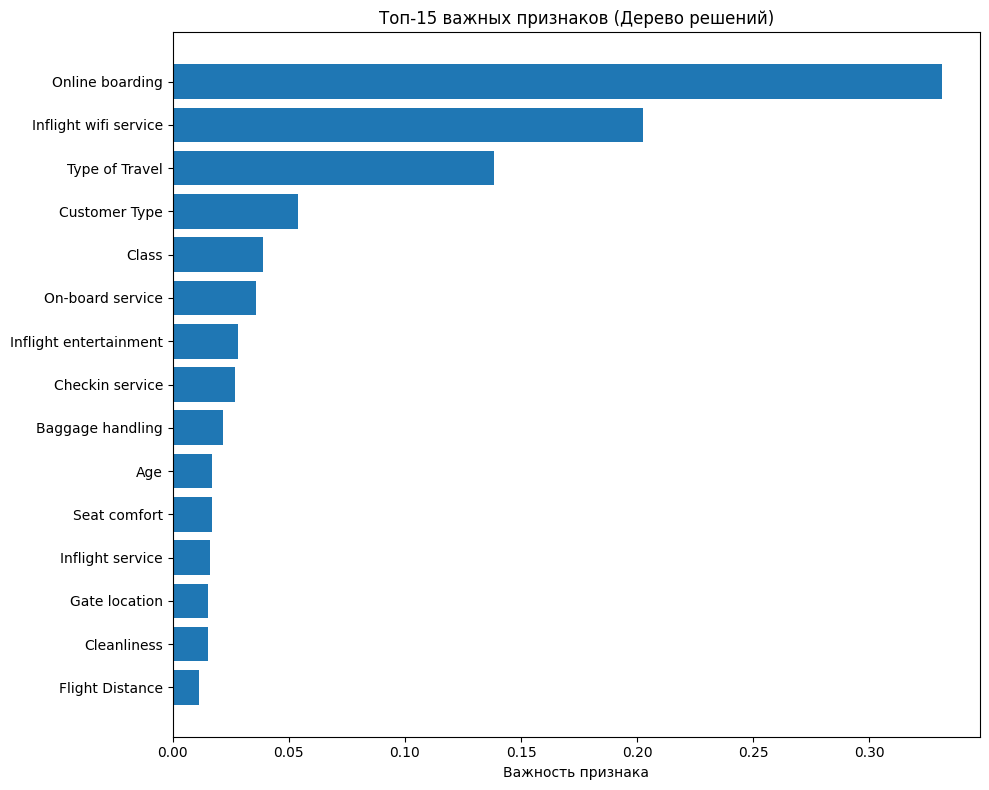

In [20]:
# Визуализация важности признаков
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Дерево решений)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Обучение моделей на сбалансированных данных


In [21]:
# применяем oversampling для балансировки всего датасета (как требуется для GridSearchCV)
# затем разделим на train/val для финальной оценки

# функция для балансировки данных методом oversampling
def balance_data(X, y, random_state=42):
    # объединяем X и y для удобства работы
    
    if isinstance(X, pd.DataFrame):
        df = X.copy()
    else:
        df = pd.DataFrame(X)
    df['target'] = y
    
    # разделяем по классам
    class_counts = y.value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    
    df_majority = df[df['target'] == majority_class]
    df_minority = df[df['target'] == minority_class]
    
    # увеличиваем меньший класс до размера большего
    df_minority_upsampled = resample(
        df_minority,
        replace=True,
        n_samples=len(df_majority),
        random_state=random_state
    )
    
    # объединяем
    df_balanced = pd.concat([df_majority, df_minority_upsampled])
    
    # перемешиваем данные
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # разделяем на X и y
    y_balanced = df_balanced['target']
    X_balanced = df_balanced.drop('target', axis=1)
    
    return X_balanced, y_balanced

# балансировка
X_balanced_full, y_balanced_full = balance_data(X_encoded, y, random_state=42)

print(f"Размер датасета до балансировки: {X_encoded.shape}")
print(f"Размер датасета после балансировки: {X_balanced_full.shape}")
print(f"\nРаспределение классов до балансировки:")
print(y.value_counts())
print(f"\nРаспределение классов после балансировки:")
print(pd.Series(y_balanced_full).value_counts())

# Разделяем сбалансированные данные на train/val для финальной оценки
X_train_balanced, X_val_balanced, y_train_balanced, y_val_balanced = train_test_split(
    X_balanced_full, y_balanced_full, test_size=0.2, random_state=42, stratify=y_balanced_full
)

print(f"\nРазмер обучающей выборки (сбалансированной): {X_train_balanced.shape}")
print(f"Размер валидационной выборки (сбалансированной): {X_val_balanced.shape}")


Размер датасета до балансировки: (103910, 23)
Размер датасета после балансировки: (117766, 23)

Распределение классов до балансировки:
satisfaction_numeric
0    58883
1    45027
Name: count, dtype: int64

Распределение классов после балансировки:
target
1    58883
0    58883
Name: count, dtype: int64

Размер обучающей выборки (сбалансированной): (94212, 23)
Размер валидационной выборки (сбалансированной): (23554, 23)


### 5.1. Логистическая регрессия на сбалансированных данных


In [22]:
grid_search_log_reg_balanced = GridSearchCV(
    log_reg,
    param_grid_log_reg,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_log_reg_balanced.fit(X_balanced_full, y_balanced_full)

print(f"\nЛучшие параметры: {grid_search_log_reg_balanced.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_log_reg_balanced.best_score_:.4f}")


Fitting 5 folds for each of 14 candidates, totalling 70 fits

Лучшие параметры: {'penalty': None, 'solver': 'newton-cg'}
Лучший F1-score (кросс-валидация): 0.8663


In [23]:
# обучаем модель с лучшими параметрами на сбалансированной обучающей выборке
best_log_reg_balanced = grid_search_log_reg_balanced.best_estimator_
best_log_reg_balanced.fit(X_train_balanced, y_train_balanced)

# предсказания на валидационной выборке
y_pred_log_reg_balanced = best_log_reg_balanced.predict(X_val)

# метрики
accuracy_log_reg_balanced = accuracy_score(y_val, y_pred_log_reg_balanced)
precision_log_reg_balanced = precision_score(y_val, y_pred_log_reg_balanced)
recall_log_reg_balanced = recall_score(y_val, y_pred_log_reg_balanced)
f1_log_reg_balanced = f1_score(y_val, y_pred_log_reg_balanced)

print("Метрики логистической регрессии на сбалансированных данных (валидационная выборка):")
print(f"Accuracy: {accuracy_log_reg_balanced:.4f}")
print(f"Precision: {precision_log_reg_balanced:.4f}")
print(f"Recall: {recall_log_reg_balanced:.4f}")
print(f"F1-score: {f1_log_reg_balanced:.4f}")
print(f"\nПараметры модели: {grid_search_log_reg_balanced.best_params_}")


Метрики логистической регрессии на сбалансированных данных (валидационная выборка):
Accuracy: 0.8689
Precision: 0.8408
Recall: 0.8604
F1-score: 0.8505

Параметры модели: {'penalty': None, 'solver': 'newton-cg'}


### 5.2. KNN на сбалансированных данных


In [24]:
grid_search_knn_balanced = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_knn_balanced.fit(X_balanced_full, y_balanced_full)

print(f"\nЛучшие параметры: {grid_search_knn_balanced.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_knn_balanced.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits

Лучшие параметры: {'n_neighbors': 10, 'weights': 'distance'}
Лучший F1-score (кросс-валидация): 0.8397


In [25]:
# снова обучаем модель с лучшими параметрами на сбалансированной обучающей выборке
best_knn_balanced = grid_search_knn_balanced.best_estimator_
best_knn_balanced.fit(X_train_balanced, y_train_balanced)

# предсказания на валидационной выборке
y_pred_knn_balanced = best_knn_balanced.predict(X_val)

# метрики
accuracy_knn_balanced = accuracy_score(y_val, y_pred_knn_balanced)
precision_knn_balanced = precision_score(y_val, y_pred_knn_balanced)
recall_knn_balanced = recall_score(y_val, y_pred_knn_balanced)
f1_knn_balanced = f1_score(y_val, y_pred_knn_balanced)

print("Метрики KNN на сбалансированных данных (валидационная выборка):")
print(f"Accuracy: {accuracy_knn_balanced:.4f}")
print(f"Precision: {precision_knn_balanced:.4f}")
print(f"Recall: {recall_knn_balanced:.4f}")
print(f"F1-score: {f1_knn_balanced:.4f}")
print(f"\nПараметры модели: {grid_search_knn_balanced.best_params_}")


Метрики KNN на сбалансированных данных (валидационная выборка):
Accuracy: 0.9327
Precision: 0.9377
Recall: 0.9048
F1-score: 0.9210

Параметры модели: {'n_neighbors': 10, 'weights': 'distance'}


### 5.3. Дерево решений на сбалансированных данных


In [26]:
grid_search_dt_balanced = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt_balanced.fit(X_balanced_full, y_balanced_full)

print(f"\nЛучшие параметры: {grid_search_dt_balanced.best_params_}")
print(f"Лучший F1-score (кросс-валидация): {grid_search_dt_balanced.best_score_:.4f}")


Fitting 5 folds for each of 105 candidates, totalling 525 fits

Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
Лучший F1-score (кросс-валидация): 0.9666


In [27]:
# и опять обучаем модель с лучшими параметрами на сбалансированной обучающей выборке
best_dt_balanced = grid_search_dt_balanced.best_estimator_
best_dt_balanced.fit(X_train_balanced, y_train_balanced)

# предсказания на валидационной выборке
y_pred_dt_balanced = best_dt_balanced.predict(X_val)

# метрики
accuracy_dt_balanced = accuracy_score(y_val, y_pred_dt_balanced)
precision_dt_balanced = precision_score(y_val, y_pred_dt_balanced)
recall_dt_balanced = recall_score(y_val, y_pred_dt_balanced)
f1_dt_balanced = f1_score(y_val, y_pred_dt_balanced)

print("Метрики дерева решений на сбалансированных данных (валидационная выборка):")
print(f"Accuracy: {accuracy_dt_balanced:.4f}")
print(f"Precision: {precision_dt_balanced:.4f}")
print(f"Recall: {recall_dt_balanced:.4f}")
print(f"F1-score: {f1_dt_balanced:.4f}")
print(f"\nПараметры модели: {grid_search_dt_balanced.best_params_}")


Метрики дерева решений на сбалансированных данных (валидационная выборка):
Accuracy: 0.9869
Precision: 0.9885
Recall: 0.9812
F1-score: 0.9848

Параметры модели: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}


### 5.4. Важность признаков для дерева решений на сбалансированных данных


In [28]:
# важность признаков для сбалансированной модели
feature_importance_balanced = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': best_dt_balanced.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков для сбалансированной модели (топ-15):")
print(feature_importance_balanced.head(15))

print(f"\nВажность признака 'Overall final': {feature_importance_balanced[feature_importance_balanced['feature'] == 'Overall final']['importance'].values[0]:.4f}")
print(f"Место в рейтинге: {feature_importance_balanced[feature_importance_balanced['feature'] == 'Overall final'].index[0] + 1}")


Важность признаков для сбалансированной модели (топ-15):
                   feature  importance
12         Online boarding    0.302060
7    Inflight wifi service    0.192523
4           Type of Travel    0.124989
5                    Class    0.049004
14  Inflight entertainment    0.048575
1            Customer Type    0.047713
3                      Age    0.027368
10           Gate location    0.027158
18         Checkin service    0.025515
6          Flight Distance    0.025138
17        Baggage handling    0.021775
2            Overall final    0.017639
13            Seat comfort    0.016409
19        Inflight service    0.016108
16        Leg room service    0.010795

Важность признака 'Overall final': 0.0176
Место в рейтинге: 3


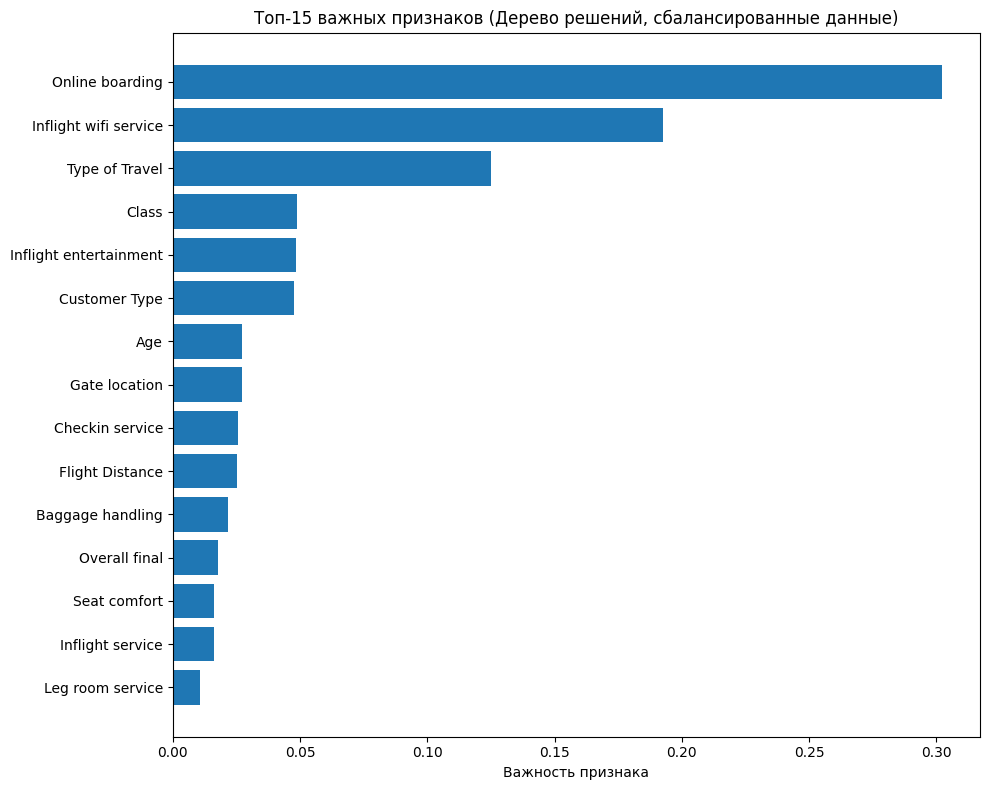

In [29]:
# визуализируем важность признаков для сбалансированной модели
plt.figure(figsize=(10, 8))
top_features_balanced = feature_importance_balanced.head(15)
plt.barh(range(len(top_features_balanced)), top_features_balanced['importance'])
plt.yticks(range(len(top_features_balanced)), top_features_balanced['feature'])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Дерево решений, сбалансированные данные)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Сравнение результатов

### 6.1. Сводная таблица метрик


In [30]:
# сводная таблица результатов
results = pd.DataFrame({
    'Модель': [
        'Логистическая регрессия (обычные данные)',
        'KNN (обычные данные)',
        'Дерево решений (обычные данные)',
        'Логистическая регрессия (сбалансированные данные)',
        'KNN (сбалансированные данные)',
        'Дерево решений (сбалансированные данные)'
    ],
    'Accuracy': [
        accuracy_log_reg, accuracy_knn, accuracy_dt,
        accuracy_log_reg_balanced, accuracy_knn_balanced, accuracy_dt_balanced
    ],
    'Precision': [
        precision_log_reg, precision_knn, precision_dt,
        precision_log_reg_balanced, precision_knn_balanced, precision_dt_balanced
    ],
    'Recall': [
        recall_log_reg, recall_knn, recall_dt,
        recall_log_reg_balanced, recall_knn_balanced, recall_dt_balanced
    ],
    'F1-score': [
        f1_log_reg, f1_knn, f1_dt,
        f1_log_reg_balanced, f1_knn_balanced, f1_dt_balanced
    ]
})

results = results.sort_values('F1-score', ascending=False)
print("Сводная таблица результатов:")
print(results.to_string(index=False))


Сводная таблица результатов:
                                           Модель  Accuracy  Precision   Recall  F1-score
         Дерево решений (сбалансированные данные)  0.986912   0.988477 0.981233  0.984842
                  Дерево решений (обычные данные)  0.946781   0.939370 0.937701  0.938535
                    KNN (сбалансированные данные)  0.932730   0.937737 0.904831  0.920990
         Логистическая регрессия (обычные данные)  0.876335   0.870722 0.839200  0.854671
Логистическая регрессия (сбалансированные данные)  0.868925   0.840803 0.860411  0.850494
                             KNN (обычные данные)  0.745742   0.725106 0.665519  0.694036


### 6.2. Сравнение влияния балансировки данных


In [32]:
# сравнение F1-score до и после балансировки
comparison = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'KNN', 'Дерево решений'],
    'F1 (обычные данные)': [f1_log_reg, f1_knn, f1_dt],
    'F1 (сбалансированные данные)': [f1_log_reg_balanced, f1_knn_balanced, f1_dt_balanced],
    'Разница': [
        f1_log_reg_balanced - f1_log_reg,
        f1_knn_balanced - f1_knn,
        f1_dt_balanced - f1_dt
    ]
})

comparison['Улучшение'] = comparison['Разница'].apply(lambda x: 'Да' if x > 0 else 'Нет')
print("Сравнение влияния балансировки данных:")
print(comparison.to_string(index=False))


Сравнение влияния балансировки данных:
                 Модель  F1 (обычные данные)  F1 (сбалансированные данные)   Разница Улучшение
Логистическая регрессия             0.854671                      0.850494 -0.004177       Нет
                    KNN             0.694036                      0.920990  0.226954        Да
         Дерево решений             0.938535                      0.984842  0.046307        Да


## 7. Выводы

### 7.1. Анализ важности признаков


In [33]:
print("Топ-10 важных признаков (обычные данные):")
print(feature_importance.head(10)[['feature', 'importance']].to_string(index=False))

Топ-10 важных признаков (обычные данные):
               feature  importance
       Online boarding    0.331076
 Inflight wifi service    0.202496
        Type of Travel    0.138389
         Customer Type    0.053962
                 Class    0.039029
      On-board service    0.035720
Inflight entertainment    0.028075
       Checkin service    0.026845
      Baggage handling    0.021696
                   Age    0.017032


In [34]:
print("Топ-10 важных признаков (сбалансированные данные):")
print(feature_importance_balanced.head(10)[['feature', 'importance']].to_string(index=False))

Топ-10 важных признаков (сбалансированные данные):
               feature  importance
       Online boarding    0.302060
 Inflight wifi service    0.192523
        Type of Travel    0.124989
                 Class    0.049004
Inflight entertainment    0.048575
         Customer Type    0.047713
                   Age    0.027368
         Gate location    0.027158
       Checkin service    0.025515
       Flight Distance    0.025138


### 7.2.Ну точно прям выводы


In [37]:
# лучшая модель
best_model_idx = results['F1-score'].idxmax()
best_model = results.loc[best_model_idx]

print("="*70)
print("ВЫВОДЫ")
print("="*70)

print(f"\n1. ЛУЧШАЯ МОДЕЛЬ:")
print(f"   Модель: {best_model['Модель']}")
print(f"   F1-score: {best_model['F1-score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   Precision: {best_model['Precision']:.4f}")
print(f"   Recall: {best_model['Recall']:.4f}")

print(f"\n2. СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ:")
print(f"   Диапазон F1-score: от {results['F1-score'].min():.4f} до {results['F1-score'].max():.4f}")
print(f"   Разница между лучшей и худшей моделью: {results['F1-score'].max() - results['F1-score'].min():.4f}")

if results['F1-score'].max() - results['F1-score'].min() > 0.05:
    print("Качество моделей значительно различается")
else:
    print("Качество моделей различается незначительно")

print(f"\n3. ВЛИЯНИЕ БАЛАНСИРОВКИ ДАННЫХ:")
for idx, row in comparison.iterrows():
    model_name = row['Модель']
    diff = row['Разница']
    if diff > 0:
        print(f"   {model_name}: балансировка улучшила качество на {diff:.4f}")
    elif diff < 0:
        print(f"   {model_name}: балансировка ухудшила качество на {abs(diff):.4f}")
    else:
        print(f"   {model_name}: балансировка не повлияла на качество")

print(f"\n4. ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ КАЖДОЙ МОДЕЛИ:")
print(f"   Логистическая регрессия (обычные): {grid_search_log_reg.best_params_}")
print(f"   Логистическая регрессия (сбалансированные): {grid_search_log_reg_balanced.best_params_}")
print(f"   KNN (обычные): {grid_search_knn.best_params_}")
print(f"   KNN (сбалансированные): {grid_search_knn_balanced.best_params_}")
print(f"   Дерево решений (обычные): {grid_search_dt.best_params_}")
print(f"   Дерево решений (сбалансированные): {grid_search_dt_balanced.best_params_}")

print("\n" + "="*70)


ВЫВОДЫ

1. ЛУЧШАЯ МОДЕЛЬ:
   Модель: Дерево решений (сбалансированные данные)
   F1-score: 0.9848
   Accuracy: 0.9869
   Precision: 0.9885
   Recall: 0.9812

2. СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ:
   Диапазон F1-score: от 0.6940 до 0.9848
   Разница между лучшей и худшей моделью: 0.2908
Качество моделей значительно различается

3. ВЛИЯНИЕ БАЛАНСИРОВКИ ДАННЫХ:
   Логистическая регрессия: балансировка ухудшила качество на 0.0042
   KNN: балансировка улучшила качество на 0.2270
   Дерево решений: балансировка улучшила качество на 0.0463

4. ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ КАЖДОЙ МОДЕЛИ:
   Логистическая регрессия (обычные): {'penalty': 'l2', 'solver': 'liblinear'}
   Логистическая регрессия (сбалансированные): {'penalty': None, 'solver': 'newton-cg'}
   KNN (обычные): {'n_neighbors': 6, 'weights': 'distance'}
   KNN (сбалансированные): {'n_neighbors': 10, 'weights': 'distance'}
   Дерево решений (обычные): {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1}
   Дерево решений (сбалансированные):